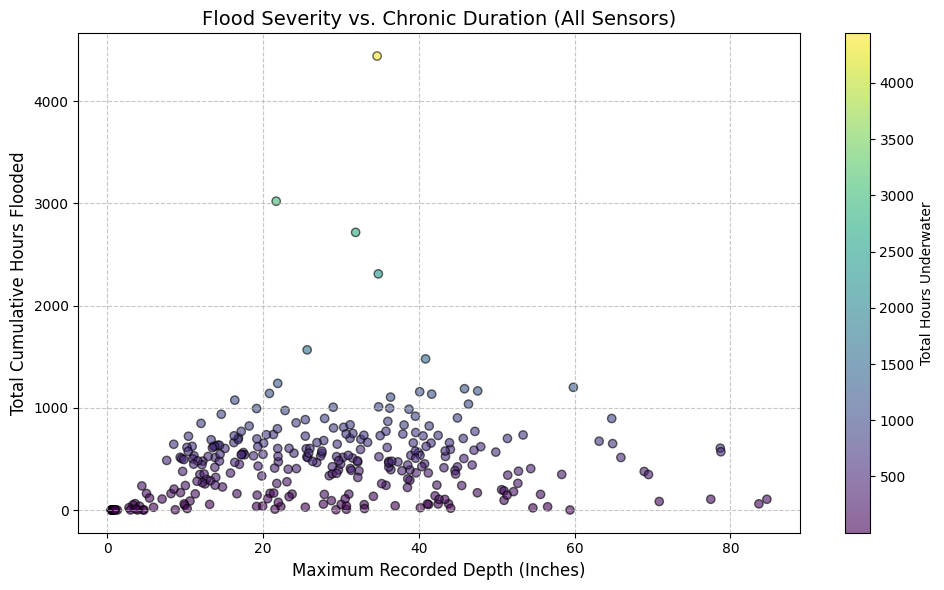

Top 10 Most Chronically Flooded Locations (All Boroughs):
                                name  total_hours  max_depth
115     BX - Ditmars St/Hunter Ave 2  4439.783333  34.645669
93   BK - Fountain Ave/Flatlands Ave  3020.150000  21.692913
132       BK - Mermaid Ave/W 32nd St  2715.316667  31.889764
242             BK - 41st St/2nd Ave  2309.383333  34.803150
44   Q - Brookville Blvd/ Snake Rd 3  1566.350000  25.669291
147               Q - Davenport Ct 1  1478.166667  40.866142
199      BX - Webster Ave/E 166th St  1238.450000  21.889764
37                  Q - Russell St 1  1199.966667  59.842520
200            Q - 100th St/34th Ave  1186.266667  45.866142
25                   Q - Beach 84 St  1164.816667  47.559055


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the floods-only dataset
df = pd.read_parquet('floodnet_floods_only.parquet')

# 2. Calculate total hours of flooding per sensor
# Since measurements are roughly 1-minute intervals, 60 rows = 1 hour
sensor_impact = df.groupby(['deployment_id', 'name']).agg(
    total_minutes=('depth_inches', 'count'),
    max_depth=('depth_inches', 'max'),
    avg_depth=('depth_inches', 'mean')
).reset_index()

sensor_impact['total_hours'] = sensor_impact['total_minutes'] / 60

# 3. Visualization: Intensity vs. Duration
plt.figure(figsize=(10, 6))

# Scatter plot: X = Max Depth, Y = Total Hours
plt.scatter(
    sensor_impact['max_depth'], 
    sensor_impact['total_hours'],
    alpha=0.6,
    c=sensor_impact['total_hours'],
    cmap='viridis',
    edgecolors='k'
)

plt.title("Flood Severity vs. Chronic Duration (All Sensors)", fontsize=14)
plt.xlabel("Maximum Recorded Depth (Inches)", fontsize=12)
plt.ylabel("Total Cumulative Hours Flooded", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.colorbar(label='Total Hours Underwater')

plt.tight_layout()
plt.savefig('flood_intensity_duration.png', dpi=300)
plt.show()

# 4. Identify the Top 10 "Hotspots" across the whole city
print("Top 10 Most Chronically Flooded Locations (All Boroughs):")
print(sensor_impact.sort_values('total_hours', ascending=False).head(10)[['name', 'total_hours', 'max_depth']])